In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cdo import Cdo
import pandas as pd
import warnings
import cftime
from xarray.coding.times import SerializationWarning

In [20]:
def yearly_mean(data_array):
    t0 = data_array.time.values[0]
    start_year = int(data_array.time.min().dt.year)
    end_year = int(data_array.time.max().dt.year)
    years = np.linspace(start_year, end_year, end_year - start_year + 1)
    times = []
    means = []
    for year in years:
        year_data = data_array.sel(time=data_array['time'].dt.year == year)
    
        if isinstance(t0, np.datetime64):
            times.append(year_data.time.mean().values)
        elif isinstance(t0, cftime.datetime):
            times.append(year_data.time.mean().item())
        else:
            print(f"Unknown time type: {type(t0)}")
        
         # --- Compute days-per-month weights ---
        days_in_month = year_data['time'].dt.days_in_month
        weights = days_in_month / days_in_month.sum()
        # --- Compute weighted time mean ---
        timmean = year_data.weighted(weights).mean('time')#.to_dataset(name=variable)
        means.append(timmean)
    result = xr.concat(means, dim='time')
    result = result.assign_coords(time=("time", times))
    # print(type(result.time.values[0]))
    return result


### Opening data

#### Retrieving data filepaths

In [10]:
# Get current working directory
script_dir = os.getcwd()

data_pi = script_dir + '/pi_control_smhi'
data_2K = script_dir + '/gwl2p0_knmi'
data_4K = script_dir + '/gwl4p0_dmi'

def filepath(data_scenario, months):
    if months == 1:
        file_tas = [f for f in os.listdir(data_scenario) if f.startswith('detrended_tas')][0]
        file_prsn = [f for f in os.listdir(data_scenario) if f.startswith('detrended_prsn')][0]
        file_pr = [f for f in os.listdir(data_scenario) if f.startswith('detrended_pr.')][0]
    elif months == 12:
        file_tas = [f for f in os.listdir(data_scenario) if f.startswith('yearly_tas')][0]
        file_prsn = [f for f in os.listdir(data_scenario) if f.startswith('yearly_prsn')][0]
        file_pr = [f for f in os.listdir(data_scenario) if f.startswith('yearly_pr.')][0]
    else:
        print('specify yearly or monthly data')
    return data_scenario + '/' + file_tas, data_scenario + '/' + file_prsn, data_scenario + '/' + file_pr

file_tas_pi, file_prsn_pi, file_pr_pi = filepath(data_pi, 1)
file_tas_2K, file_prsn_2K, file_pr_2K = filepath(data_2K, 1)
file_tas_4K, file_prsn_4K, file_pr_4K = filepath(data_4K, 1)

yearly_file_tas_pi, yearly_file_prsn_pi, yearly_file_pr_pi = filepath(data_pi, 12)
yearly_file_tas_2K, yearly_file_prsn_2K, yearly_file_pr_2K = filepath(data_2K, 12)
yearly_file_tas_4K, yearly_file_prsn_4K, yearly_file_pr_4K = filepath(data_4K, 12)

#### Opening data

In [11]:
warnings.simplefilter("ignore", SerializationWarning) # suppresses the warning that datetime does not work

tas_pi = xr.open_dataset(file_tas_pi)['__xarray_dataarray_variable__'] #  MISSCHIEN FF AANPASSEN DAT HET MET JUISTE NAAM WORDT WEGGESCHREVEN
pr_pi = xr.open_dataset(file_pr_pi)['__xarray_dataarray_variable__']
prsn_pi = xr.open_dataset(file_prsn_pi)['__xarray_dataarray_variable__']

tas_pi_yearly = xr.open_dataset(yearly_file_tas_pi)['__xarray_dataarray_variable__']
pr_pi_yearly = xr.open_dataset(yearly_file_pr_pi)['__xarray_dataarray_variable__']
prsn_pi_yearly = xr.open_dataset(yearly_file_prsn_pi)['__xarray_dataarray_variable__']

tas_2K = xr.open_dataset(file_tas_2K)['__xarray_dataarray_variable__']
pr_2K = xr.open_dataset(file_pr_2K)['__xarray_dataarray_variable__']
prsn_2K = xr.open_dataset(file_prsn_2K)['__xarray_dataarray_variable__']

tas_2K_yearly = xr.open_dataset(yearly_file_tas_2K)['__xarray_dataarray_variable__']
pr_2K_yearly = xr.open_dataset(yearly_file_pr_2K)['__xarray_dataarray_variable__']
prsn_2K_yearly = xr.open_dataset(yearly_file_prsn_2K)['__xarray_dataarray_variable__']

tas_4K = xr.open_dataset(file_tas_4K)['__xarray_dataarray_variable__']
pr_4K = xr.open_dataset(file_pr_4K)['__xarray_dataarray_variable__']
prsn_4K = xr.open_dataset(file_prsn_4K)['__xarray_dataarray_variable__']

tas_4K_yearly = xr.open_dataset(yearly_file_tas_4K)['__xarray_dataarray_variable__']
pr_4K_yearly = xr.open_dataset(yearly_file_pr_4K)['__xarray_dataarray_variable__']
prsn_4K_yearly = xr.open_dataset(yearly_file_prsn_4K)['__xarray_dataarray_variable__']


### Obtaining snow fraction

In [12]:
def snow_fraction(prsn, pr):
    pr = pr.where(pr >= 0)
    prsn = prsn.where(pr >= 0)

    prsn = prsn.where(prsn >= 0, 0)
    
    difference = pr-prsn
    prsn_overshot = difference.where(difference < 0, 0)
    print(prsn_overshot.min().values)
    prsn = prsn + prsn_overshot # make it so snowfall cannot be larger than precipitation
    
    snow_fraction = prsn/pr

    if (snow_fraction > 1.1).any():
        print('snow_fraction larger than 1.1 found')
        
    return snow_fraction

In [13]:
snfr_pi = snow_fraction(prsn_pi, pr_pi)
snfr_2K = snow_fraction(prsn_2K, pr_2K)
snfr_4K = snow_fraction(prsn_4K, pr_4K)

-4.203098772924588
-4.21791815447287
-3.7364004520808978


In [21]:
snfr_pi_yearly = yearly_mean(snfr_pi)
snfr_2K_yearly = yearly_mean(snfr_2K)
snfr_4K_yearly = yearly_mean(snfr_4K)

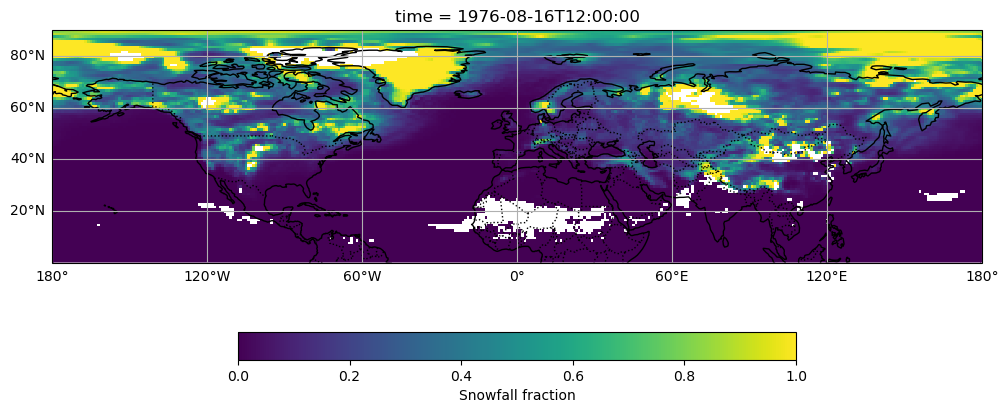

In [14]:
# snfr_2d = snfr_2K.sel(time=pd.to_datetime('2057-01-16 12:00:00'))
snfr_2d = snfr_2K.isel(time=307)

# Create a figure and axis with a map projection
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# Plot the data
snfr_2d.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),  # tells Cartopy that the data is lat/lon
    # vmin=-1.0,
    # vmax=1.0,
    cmap='viridis',              # color map
    cbar_kwargs={'label': 'Snowfall fraction', 'orientation': 'horizontal', 'shrink': 0.6}
)

# Add coastlines and borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Add gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.savefig('snfr_at_time.png')

plt.show()

### Plotting means Northern Hemisphere

In [15]:
# calculating means pi 
tas_pi_mean = tas_pi.mean(dim = ['lon', 'lat'])
tas_pi_yearly_mean = tas_pi_yearly.mean(dim = ['lon', 'lat'])

pr_pi_mean = pr_pi.mean(dim = ['lon', 'lat'])
pr_pi_yearly_mean = pr_pi_yearly.mean(dim = ['lon', 'lat'])

prsn_pi_mean = prsn_pi.mean(dim = ['lon', 'lat'])
prsn_pi_yearly_mean = prsn_pi_yearly.mean(dim = ['lon', 'lat'])

#calculating means +2K
tas_2K_mean = tas_2K.mean(dim = ['lon', 'lat'])
tas_2K_yearly_mean = tas_2K_yearly.mean(dim = ['lon', 'lat'])

pr_2K_mean = pr_2K.mean(dim = ['lon', 'lat'])
pr_2K_yearly_mean = pr_2K_yearly.mean(dim = ['lon', 'lat'])

prsn_2K_mean = prsn_2K.mean(dim = ['lon', 'lat'])
prsn_2K_yearly_mean = prsn_2K_yearly.mean(dim = ['lon', 'lat'])


# calculating means +4K
tas_4K_mean = tas_4K.mean(dim = ['lon', 'lat'])
tas_4K_yearly_mean = tas_4K_yearly.mean(dim = ['lon', 'lat'])

pr_4K_mean = pr_4K.mean(dim = ['lon', 'lat'])
pr_4K_yearly_mean = pr_4K_yearly.mean(dim = ['lon', 'lat'])

prsn_4K_mean = prsn_4K.mean(dim = ['lon', 'lat'])
prsn_4K_yearly_mean = prsn_4K_yearly.mean(dim = ['lon', 'lat'])




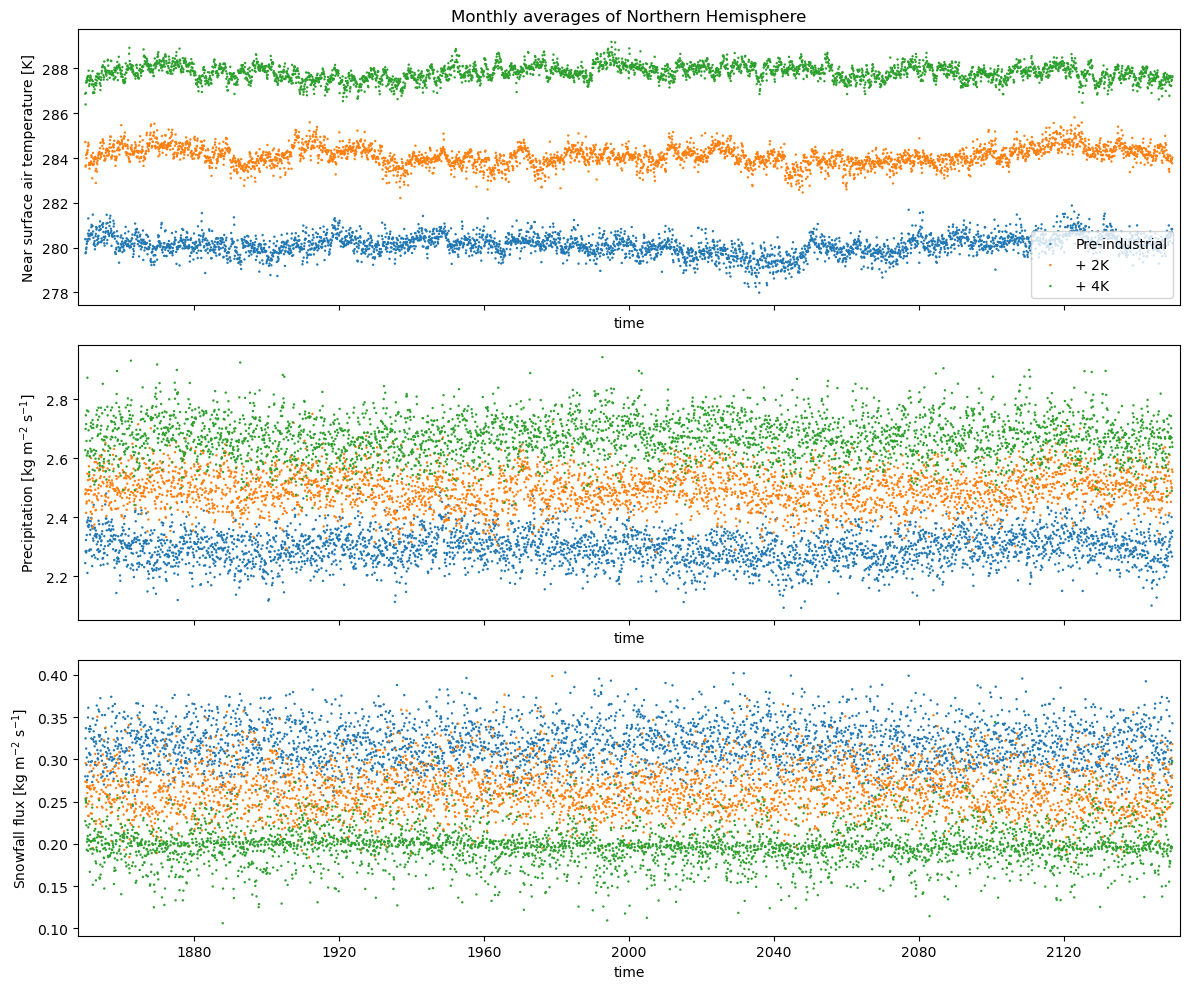

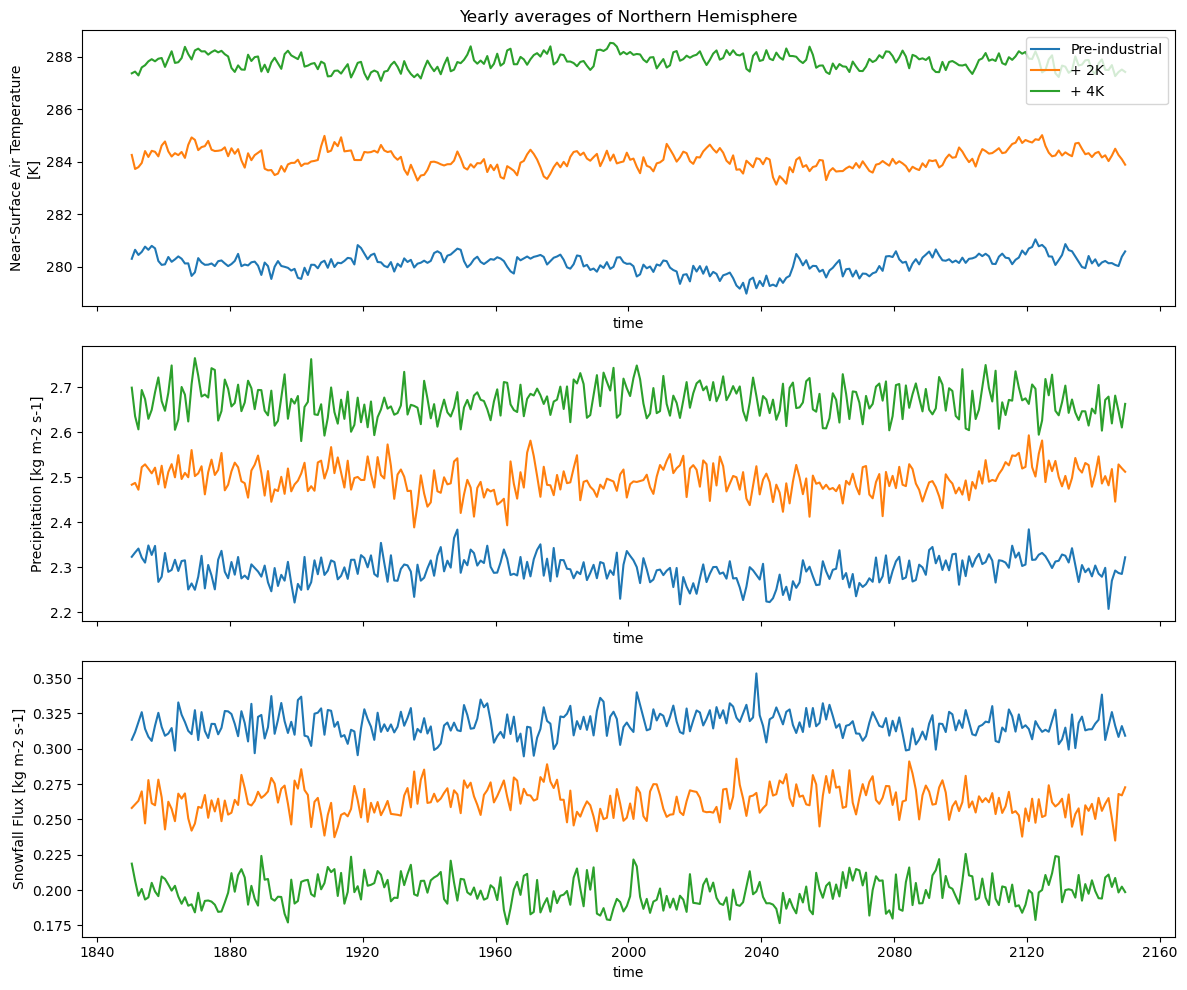

In [16]:
time_array = tas_pi.time.values
yearly_time_array = tas_pi_yearly.time.values

fig, ax = plt.subplots(3,1, figsize = (12,10), sharex = True)

tas_pi_mean.plot.scatter(x = 'time', ax = ax[0], s = 3, edgecolors = 'none', label = 'Pre-industrial')
tas_2K_mean.assign_coords(time=("time", time_array)).plot.scatter(x = 'time', ax = ax[0], s = 3, edgecolors = 'none', label = '+ 2K')
tas_4K_mean.assign_coords(time=("time", time_array)).plot.scatter(x = 'time', ax = ax[0], s = 3, edgecolors = 'none', label = '+ 4K')
ax[0].legend()
ax[0].set_title('Monthly averages of Northern Hemisphere')
ax[0].set_ylabel('Near surface air temperature [K]')

pr_pi_mean.plot.scatter(ax = ax[1], s = 3, edgecolors = 'none')
pr_2K_mean.assign_coords(time=("time", time_array)).plot.scatter(ax = ax[1], s = 3, edgecolors = 'none')
pr_4K_mean.assign_coords(time=("time", time_array)).plot.scatter(ax = ax[1], s = 3, edgecolors = 'none')
ax[1].set_ylabel('Precipitation [kg m$^{-2}$ s$^{-1}$]')

prsn_pi_mean.plot.scatter(ax = ax[2], s = 3, edgecolors = 'none')
prsn_2K_mean.assign_coords(time=("time", time_array)).plot.scatter(ax = ax[2], s = 3, edgecolors = 'none')
prsn_4K_mean.assign_coords(time=("time", time_array)).plot.scatter(ax = ax[2], s = 3, edgecolors = 'none')
ax[2].set_ylabel('Snowfall flux [kg m$^{-2}$ s$^{-1}$]')

plt.xlim(pd.to_datetime('1848-01-01'), pd.to_datetime('2152-01-20'))

fig.tight_layout()
plt.savefig('Monthly_averages_NH.png')

plt.show()

fig, ax = plt.subplots(3,1, figsize = (12,10), sharex = True)
tas_pi_yearly_mean.plot(x = 'time', ax = ax[0], label = 'Pre-industrial')
tas_2K_yearly_mean.assign_coords(time=("time", yearly_time_array)).plot(x = 'time', ax = ax[0], label = '+ 2K')
tas_4K_yearly_mean.assign_coords(time=("time", yearly_time_array)).plot(x = 'time', ax = ax[0], label = '+ 4K')
ax[0].legend()
ax[0].set_title('Yearly averages of Northern Hemisphere')

pr_pi_yearly_mean.plot(x = 'time', ax = ax[1])
pr_2K_yearly_mean.assign_coords(time=("time", yearly_time_array)).plot(x = 'time', ax = ax[1])
pr_4K_yearly_mean.assign_coords(time=("time", yearly_time_array)).plot(x = 'time', ax = ax[1])

prsn_pi_yearly_mean.plot(x = 'time', ax = ax[2])
prsn_2K_yearly_mean.assign_coords(time=("time", yearly_time_array)).plot(x = 'time', ax = ax[2])
prsn_4K_yearly_mean.assign_coords(time=("time", yearly_time_array)).plot(x = 'time', ax = ax[2])

fig.tight_layout()
plt.savefig('Yearly_averages_NH.png')
plt.show()



### Relative Variablility

#### Yearly variability

In [44]:
variability_tas_pi = tas_pi_yearly.std(dim = 'time')/(tas_pi_yearly.mean(dim = 'time'))
variability_tas_pi = variability_tas_pi.sel(lat = slice(20,90))

variability_tas_2K = tas_2K_yearly.std(dim = 'time')/(tas_2K_yearly.mean(dim = 'time'))
variability_tas_2K = variability_tas_2K.sel(lat = slice(20,90))

variability_tas_4K = tas_4K_yearly.std(dim = 'time')/(tas_4K_yearly.mean(dim = 'time'))
variability_tas_4K = variability_tas_4K.sel(lat = slice(20,90))

variability_pr_pi = pr_pi_yearly.std(dim = 'time')/(pr_pi_yearly.mean(dim = 'time'))
variability_pr_pi = variability_pr_pi.sel(lat = slice(20,90))

variability_pr_2K = pr_2K_yearly.std(dim = 'time')/(pr_2K_yearly.mean(dim = 'time'))
variability_pr_2K = variability_pr_2K.sel(lat = slice(20,90))

variability_pr_4K = pr_4K_yearly.std(dim = 'time')/(pr_4K_yearly.mean(dim = 'time'))
variability_pr_4K = variability_pr_4K.sel(lat = slice(20,90))

variability_prsn_pi = prsn_pi_yearly.std(dim = 'time')/(prsn_pi_yearly.mean(dim = 'time'))
variability_prsn_pi = variability_prsn_pi.sel(lat = slice(20,90))

variability_prsn_2K = prsn_2K_yearly.std(dim = 'time')/(prsn_2K_yearly.mean(dim = 'time'))
variability_prsn_2K = variability_prsn_2K.sel(lat = slice(20,90))

variability_prsn_4K = prsn_4K_yearly.std(dim = 'time')/(prsn_4K_yearly.mean(dim = 'time'))
variability_prsn_4K = variability_prsn_4K.sel(lat = slice(20,90))

variability_snfr_pi = snfr_pi_yearly.std(dim = 'time')/(snfr_pi_yearly.mean(dim = 'time'))
variability_snfr_pi = variability_snfr_pi.sel(lat = slice(20,90))

variability_snfr_2K = snfr_2K_yearly.std(dim = 'time')/(snfr_2K_yearly.mean(dim = 'time')) 
variability_snfr_2K = variability_snfr_2K.sel(lat = slice(20,90))

variability_snfr_4K = snfr_4K_yearly.std(dim = 'time')/(snfr_4K_yearly.mean(dim = 'time'))
variability_snfr_4K = variability_snfr_4K.sel(lat = slice(20,90))

In [58]:
def plot_variability(variabilities, titles, savename, max_scale, bar_label, colors = 'YlOrRd'):
    fig, ax = plt.subplots(3, 1, figsize=(15, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})

    # We'll store one of the plot objects for the shared colorbar
    mesh = None
    
    for i, variability in enumerate(variabilities):
        
        # Plot without creating individual colorbars
        mesh = variability.plot(
            ax=ax[i],
            transform=ccrs.PlateCarree(),
            vmin=0,
            vmax=max_scale,
            cmap=colors,
            add_colorbar=False   # <–– important
        )
    
        ax[i].set_title(titles[i])
        ax[i].coastlines()
        ax[i].add_feature(cfeature.BORDERS, linestyle=':')
        
        gl = ax[i].gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False
    
    # ---- Add ONE shared colorbar ----
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
    cbar.set_label(bar_label)
    
    plt.savefig(savename)
    plt.show()



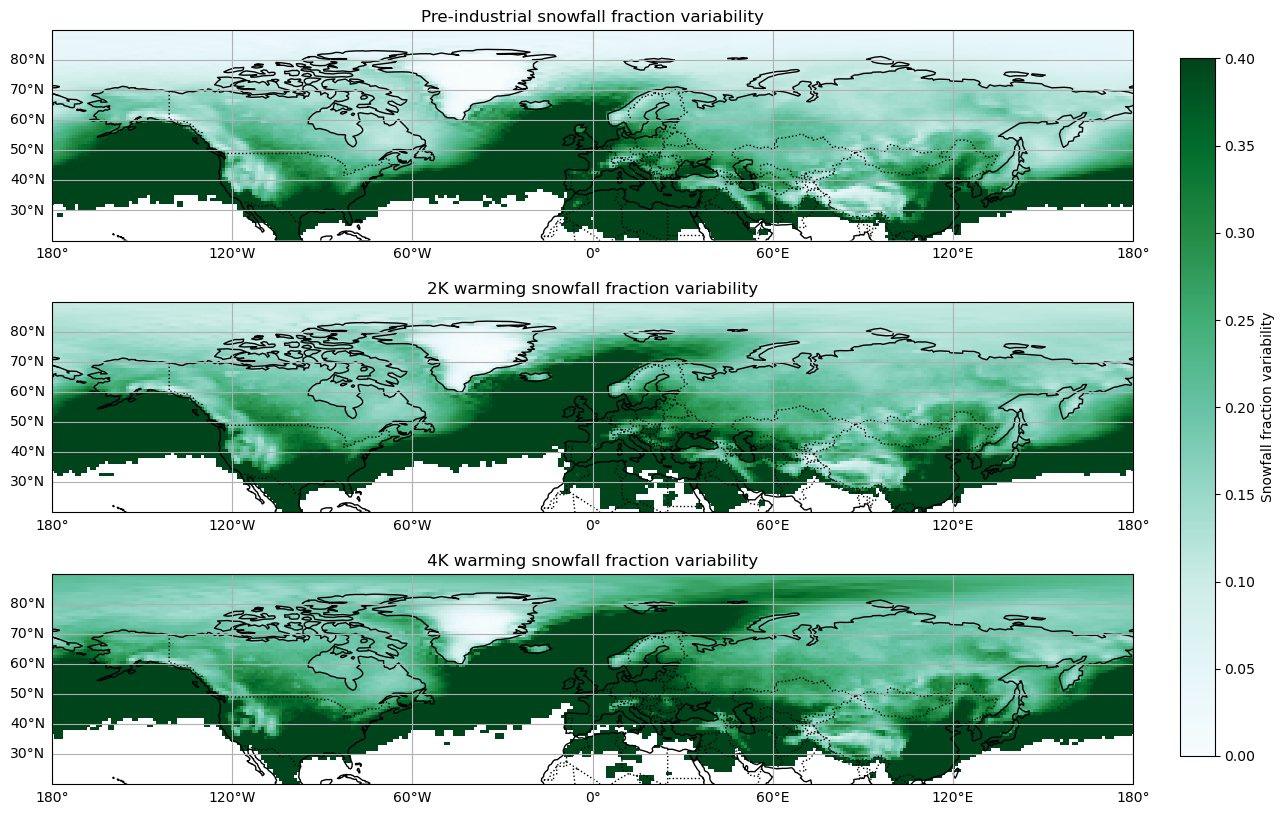

In [59]:
titles = [['Pre-industrial temperature variability (K)', '2K warming temperature variability (K)', '4K warming temperature variability (K)'],
          ['Pre-industrial presipitation variability (kg m$^{-2}$ s$^{-1}$)', '2K warming presipitation variability (kg m$^{-2}$ s$^{-1}$)', '4K warming presipitation variability (kg m$^{-2}$ s$^{-1}$)'],
          ['Pre-industrial snowfall variability (kg m$^{-2}$ s$^{-1}$)', '2K warming snowfall variability (kg m$^{-2}$ s$^{-1}$)', '4K warming snowfall variability (kg m$^{-2}$ s$^{-1}$)'],
          ['Pre-industrial snowfall fraction variability', '2K warming snowfall fraction variability', '4K warming snowfall fraction variability']]

# plot_variability([variability_tas_pi, variability_tas_2K, variability_tas_4K], titles[0], 'variability_tas.png', 0.008,'Temperature variability (K)')
# plot_variability([variability_pr_pi, variability_pr_2K, variability_pr_4K], titles[1], 'variability_pr.png', 0.9, 'Presipitation variability (kg m$^{-2}$ s$^{-1}$)', 'PuBu')
# plot_variability([variability_prsn_pi, variability_prsn_2K, variability_prsn_4K], titles[2], 'variability_prsn.png', 0.7 ,'Snowfall variability (kg m$^{-2}$ s$^{-1}$)', 'YlGnBu')
plot_variability([variability_snfr_pi, variability_snfr_2K, variability_snfr_4K], titles[3], 'variability_snfr.png', 0.4, 'Snowfall fraction variability', 'BuGn')

#### Monthly variability

In [39]:
variability_tas_pi = tas_pi.std(dim = 'time')/tas_pi_yearly.mean(dim = 'time')
variability_tas_pi = variability_tas_pi.sel(lat = slice(20,90))

variability_tas_2K = tas_2K.std(dim = 'time')/tas_2K_yearly.mean(dim = 'time')
variability_tas_2K = variability_tas_2K.sel(lat = slice(20,90))

variability_tas_4K = tas_4K.std(dim = 'time')/tas_4K_yearly.mean(dim = 'time')
variability_tas_4K = variability_tas_4K.sel(lat = slice(20,90))

variability_pr_pi = pr_pi.std(dim = 'time')/pr_pi_yearly.mean(dim = 'time')
variability_pr_pi = variability_pr_pi.sel(lat = slice(20,90))

variability_pr_2K = pr_2K.std(dim = 'time')/pr_2K_yearly.mean(dim = 'time')
variability_pr_2K = variability_pr_2K.sel(lat = slice(20,90))

variability_pr_4K = pr_4K.std(dim = 'time')/pr_4K_yearly.mean(dim = 'time')
variability_pr_4K = variability_pr_4K.sel(lat = slice(20,90))

variability_prsn_pi = prsn_pi.std(dim = 'time')/prsn_pi_yearly.mean(dim = 'time')
variability_prsn_pi = variability_prsn_pi.sel(lat = slice(20,90))

variability_prsn_2K = prsn_2K.std(dim = 'time')/prsn_2K_yearly.mean(dim = 'time')
variability_prsn_2K = variability_prsn_2K.sel(lat = slice(20,90))

variability_prsn_4K = prsn_4K.std(dim = 'time')/prsn_4K_yearly.mean(dim = 'time') 
variability_prsn_4K = variability_prsn_4K.sel(lat = slice(20,90))

variability_snfr_pi = snfr_pi.std(dim = 'time')/snfr_pi_yearly.mean(dim = 'time')
variability_snfr_pi = variability_snfr_pi.sel(lat = slice(20,90))

variability_snfr_2K = snfr_2K.std(dim = 'time')/snfr_2K_yearly.mean(dim = 'time') 
variability_snfr_2K = variability_snfr_2K.sel(lat = slice(20,90))

variability_snfr_4K = snfr_4K.std(dim = 'time')/snfr_4K_yearly.mean(dim = 'time')
variability_snfr_4K = variability_snfr_4K.sel(lat = slice(20,90))

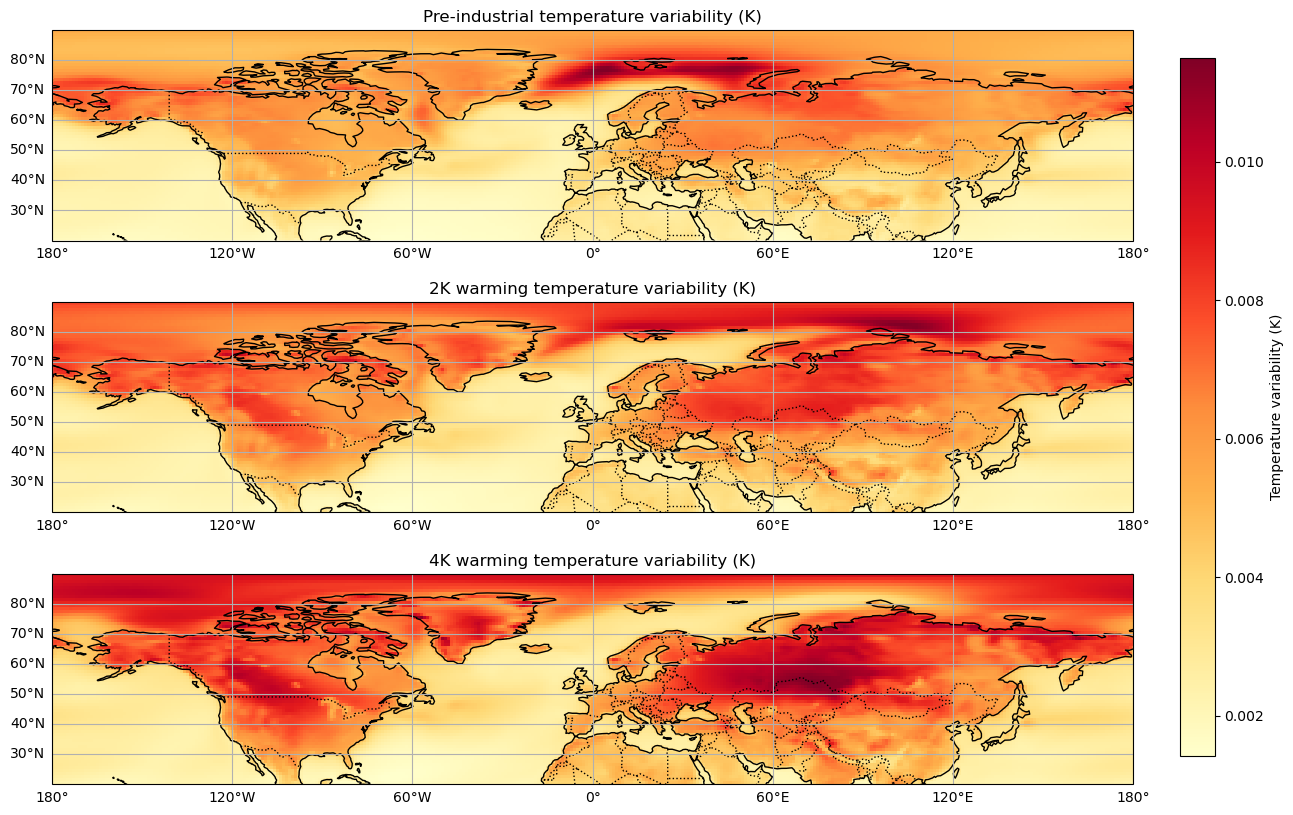

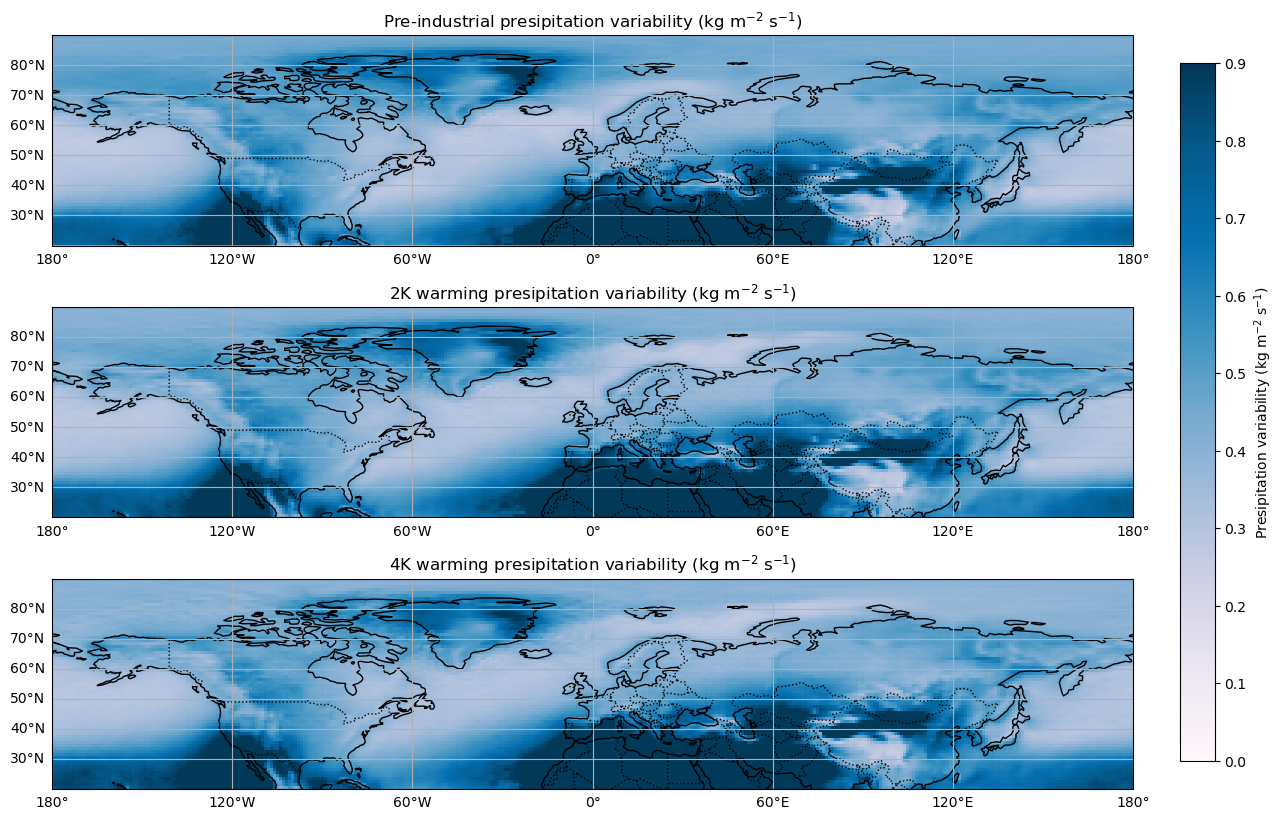

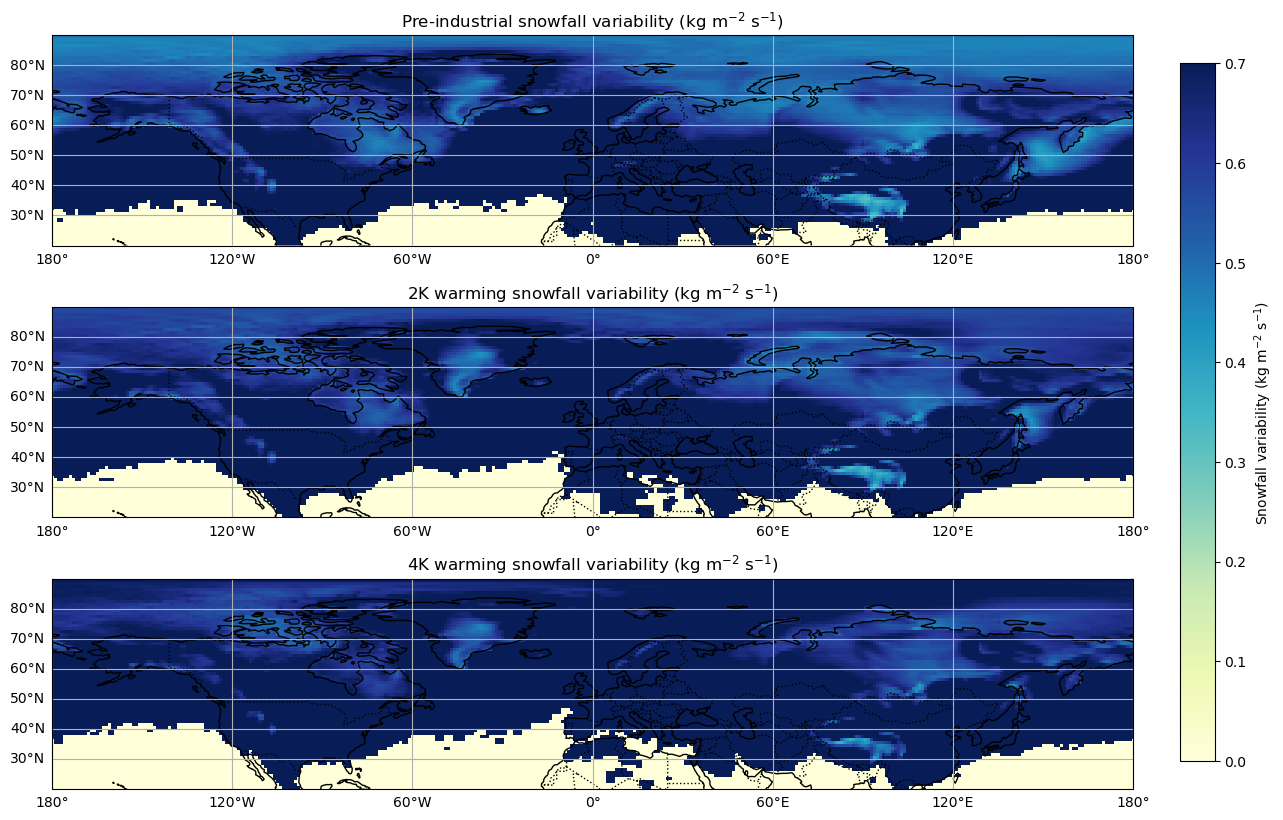

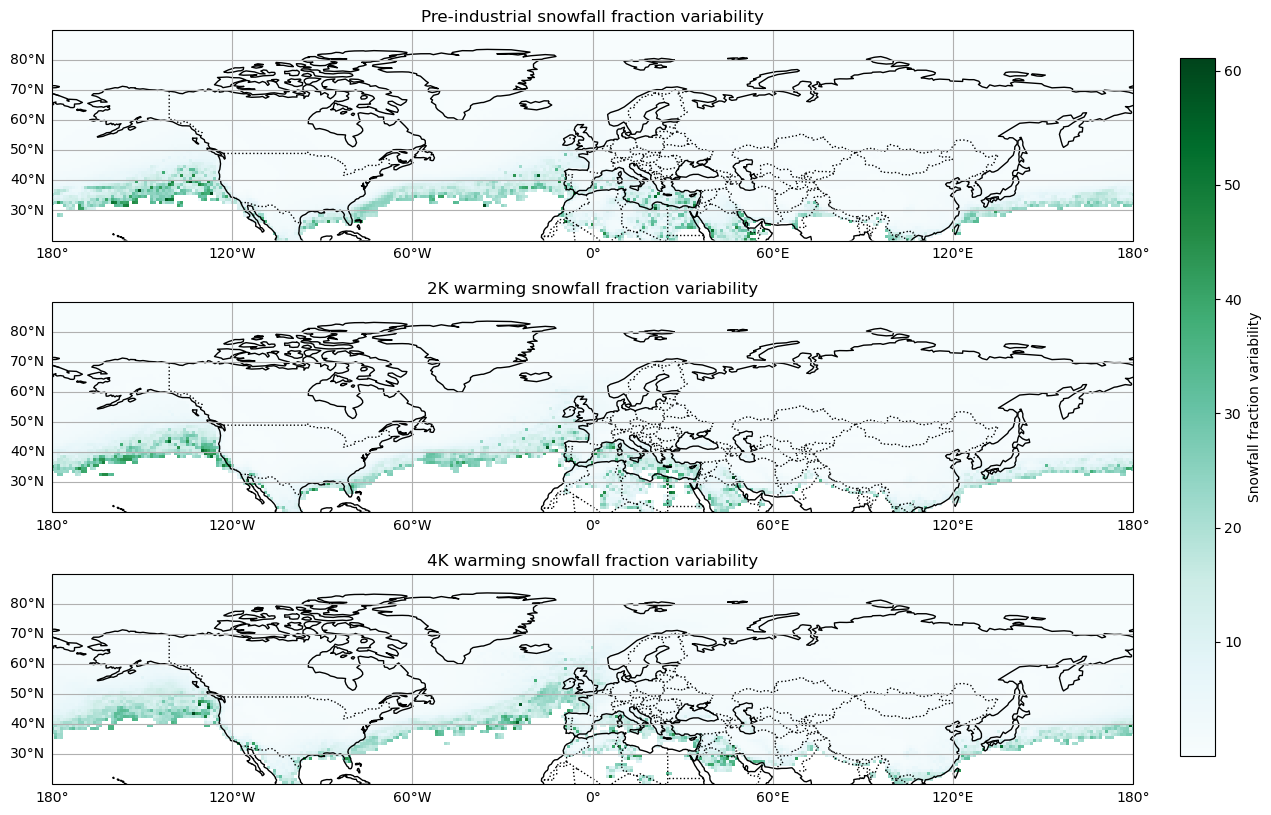

In [40]:
titles = [['Pre-industrial temperature variability (K)', '2K warming temperature variability (K)', '4K warming temperature variability (K)'],
          ['Pre-industrial presipitation variability (kg m$^{-2}$ s$^{-1}$)', '2K warming presipitation variability (kg m$^{-2}$ s$^{-1}$)', '4K warming presipitation variability (kg m$^{-2}$ s$^{-1}$)'],
          ['Pre-industrial snowfall variability (kg m$^{-2}$ s$^{-1}$)', '2K warming snowfall variability (kg m$^{-2}$ s$^{-1}$)', '4K warming snowfall variability (kg m$^{-2}$ s$^{-1}$)'],
          ['Pre-industrial snowfall fraction variability', '2K warming snowfall fraction variability', '4K warming snowfall fraction variability']]

fig, ax = plt.subplots(3, 1, figsize=(15, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})

# We'll store one of the plot objects for the shared colorbar
mesh = None

for i, variability in enumerate([variability_tas_pi, variability_tas_2K, variability_tas_4K]):
    
    # Plot without creating individual colorbars
    mesh = variability.plot(
        ax=ax[i],
        transform=ccrs.PlateCarree(),
        cmap='YlOrRd',
        add_colorbar=False   # <–– important
    )

    ax[i].set_title(titles[0][i])
    ax[i].coastlines()
    ax[i].add_feature(cfeature.BORDERS, linestyle=':')
    
    gl = ax[i].gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

# ---- Add ONE shared colorbar ----
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Temperature variability (K)')

plt.savefig('variability_tas.png')
plt.show()

fig, ax = plt.subplots(3, 1, figsize=(15, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})

# We'll store one of the plot objects for the shared colorbar
mesh = None


for i, variability in enumerate([variability_pr_pi, variability_pr_2K, variability_pr_4K]):
    
    # Plot without creating individual colorbars
    mesh = variability.plot(
        ax=ax[i],
        transform=ccrs.PlateCarree(),
        vmin=0,
        vmax=0.9,
        cmap='PuBu',
        add_colorbar=False   # <–– important
    )

    ax[i].set_title(titles[1][i])
    ax[i].coastlines()
    ax[i].add_feature(cfeature.BORDERS, linestyle=':')
    
    gl = ax[i].gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

# ---- Add ONE shared colorbar ----
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Presipitation variability (kg m$^{-2}$ s$^{-1}$)')

plt.savefig('variability_pr.png')
plt.show()


fig, ax = plt.subplots(3, 1, figsize=(15, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})

# We'll store one of the plot objects for the shared colorbar
mesh = None

for i, variability in enumerate([variability_prsn_pi, variability_prsn_2K, variability_prsn_4K]):
    
    # Plot without creating individual colorbars
    mesh = variability.plot(
        ax=ax[i],
        transform=ccrs.PlateCarree(),
        vmin=0,
        vmax=0.7,
        cmap='YlGnBu',
        add_colorbar=False   # <–– important
    )

    ax[i].set_title(titles[2][i])
    ax[i].coastlines()
    ax[i].add_feature(cfeature.BORDERS, linestyle=':')
    
    gl = ax[i].gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

# ---- Add ONE shared colorbar ---- 
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Snowfall variability (kg m$^{-2}$ s$^{-1}$)')

plt.savefig('variability_prsn.png')
plt.show()

fig, ax = plt.subplots(3, 1, figsize=(15, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})

# We'll store one of the plot objects for the shared colorbar
mesh = None
for i, variability in enumerate([variability_snfr_pi, variability_snfr_2K, variability_snfr_4K]):
    mesh = variability.plot(
        ax=ax[i],
        transform=ccrs.PlateCarree(),
        cmap='BuGn',
        add_colorbar=False,
        # vmin=0,
        # vmax=0.15
    )

    ax[i].set_title(titles[3][i])
    ax[i].coastlines()
    ax[i].add_feature(cfeature.BORDERS, linestyle=':')
    
    gl = ax[i].gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False


# ---- Add ONE shared colorbar ---- 
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Snowfall fraction variability')

plt.savefig('variability_snfr.png')
plt.show()